#  Traffic_classification Using RandomForst

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Load dataset 

In [34]:
file_path = r'C:\Users\mohmed\Desktop\Cyber Security\Porject\ftp_traffic.csv'
df = pd.read_csv(file_path)

# Feature Engineering and Pre-processing

In [35]:
df.columns = [col.strip().lower().replace('.', '_').replace(' ', '_') for col in df.columns]

# Handle missing values
df['tcp_srcport'] = pd.to_numeric(df['tcp_srcport'], errors='coerce').fillna(0)
df['tcp_dstport'] = pd.to_numeric(df['tcp_dstport'], errors='coerce').fillna(0)

#Time difference 
time_column = 'frame_time_relative'              
df[time_column] = pd.to_numeric(df[time_column], errors='coerce')
df['time_diff'] = df[time_column].diff().fillna(0)  
# Labeling traffic based on time
time_threshold = 190.713345  
df['label'] = df[time_column].apply(lambda x: 1 if x > time_threshold else 0)

# Column identification 
protocol_column = '_ws_col_protocol' 

# Features & Target
feature_columns = ['frame_len', 'tcp_dstport', protocol_column, 'time_diff']
X = df[feature_columns]
y = df['label']
df


,frame_number,ip_src,ip_dst,tcp_srcport,tcp_dstport,frame_len,_ws_col_protocol,frame_time_relative,time_diff,label
0,7,192.168.1.10,192.168.1.4,46232,21,74,TCP,12.033191,0.000000,0
1,8,192.168.1.4,192.168.1.10,21,46232,74,TCP,12.033930,0.000739,0
2,9,192.168.1.10,192.168.1.4,46232,21,66,TCP,12.033994,0.000064,0
3,10,192.168.1.4,192.168.1.10,21,46232,86,FTP,12.038224,0.004230,0
4,11,192.168.1.10,192.168.1.4,46232,21,66,TCP,12.038275,0.000051,0
...,...,...,...,...,...,...,...,...,...,...
135,284,192.168.1.10,192.168.1.4,35207,21,54,TCP,823.352307,0.000012,1
136,285,192.168.1.10,192.168.1.4,35207,21,54,TCP,823.352313,0.000006,1
137,286,192.168.1.4,192.168.1.10,6200,46435,66,TCP,823.352380,0.000067,1
138,287,192.168.1.10,192.168.1.4,46435,6200,66,TCP,823.352569,0.000189,1


# Preprocessing Pipeline

In [36]:
numeric_features = ['frame_len', 'tcp_dstport', 'time_diff']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ]
)


# Use Random Forest Classifier 

In [37]:
pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['frame_len', 'tcp_dstport',
                                                   'time_diff'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

# Evaluate Metrics

Classification Report:
              precision    recall  f1-score   support

      Normal       0.81      0.94      0.87        18
      Attack       0.95      0.83      0.89        24

    accuracy                           0.88        42
   macro avg       0.88      0.89      0.88        42
weighted avg       0.89      0.88      0.88        42



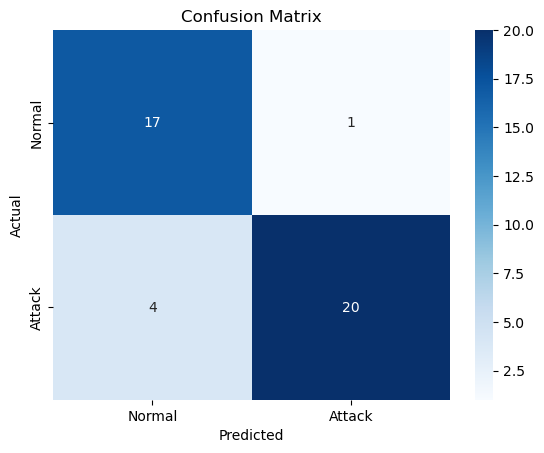

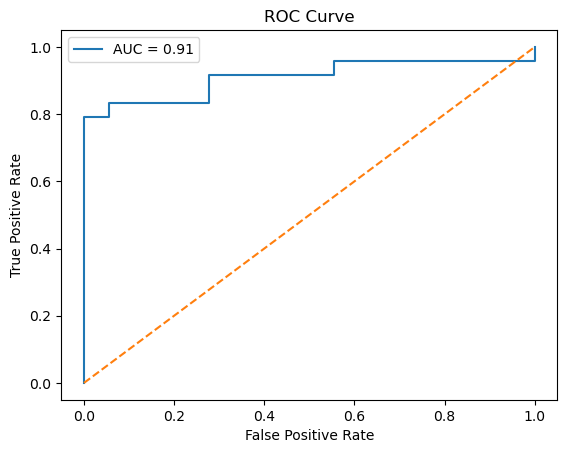

In [38]:
y_pred = pipeline.predict(X_test)
y_scores = pipeline.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "Attack"]))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Example Prediction 

In [39]:
example_input = pd.DataFrame([{
    'frame_len': 66,
    'tcp_dstport': 21,
    'time_diff': 0.05
}])

example_pred = pipeline.predict(example_input)
print(f"Prediction for new traffic (0 = Normal, 1 = Attack): {example_pred[0]}")


Prediction for new traffic (0 = Normal, 1 = Attack): 0
